<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Chem008.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

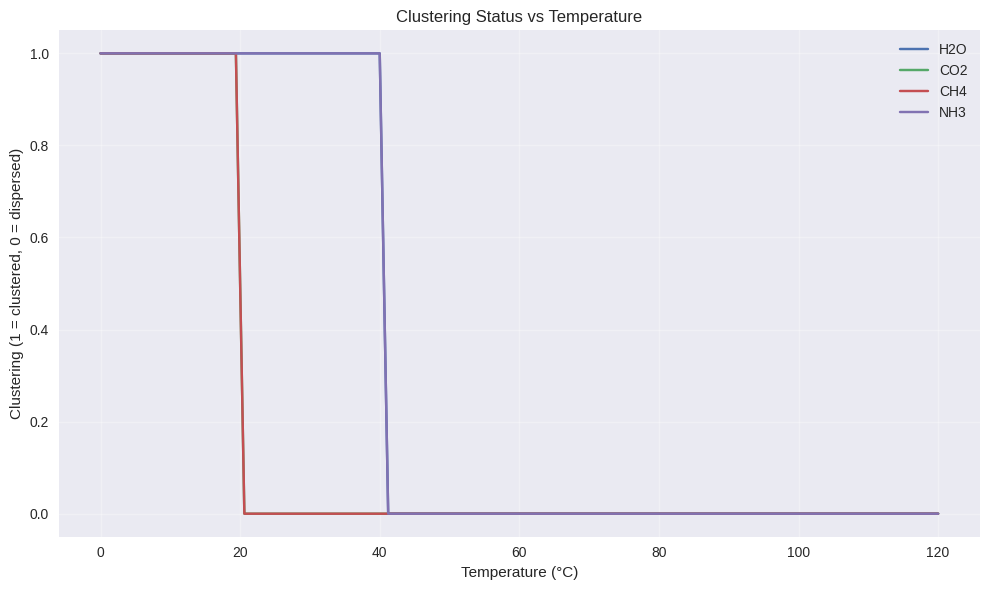

   Molecule  Temperature (°C)    Phase  Entropic Well Depth Clustering
0       H2O                 0      ice                    8  clustered
1       CO2                 0  dry ice                    6  clustered
2       CH4                 0    solid                    5  clustered
3       NH3                 0    solid                    7  clustered
4       H2O                25      ice                    8  clustered
5       CO2                25  dry ice                    6  dispersed
6       CH4                25    solid                    5  dispersed
7       NH3                25    solid                    7  clustered
8       H2O                75      ice                    8  dispersed
9       CO2                75  dry ice                    6  dispersed
10      CH4                75    solid                    5  dispersed
11      NH3                75    solid                    7  dispersed
12      H2O               100    water                    8  dispersed
13    

In [ ]:
# Chem008: Phase Transitions via HES entropic well condensation

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Define molecular parameters
molecules = {
    "H2O": {"well_depth": 8, "cluster_threshold": 6, "transitions": [(0, "ice"), (100, "water"), (101, "vapor")]},
    "CO2": {"well_depth": 6, "cluster_threshold": 5, "transitions": [(0, "dry ice"), (78, "gas")]},
    "CH4": {"well_depth": 5, "cluster_threshold": 4, "transitions": [(0, "solid"), (90, "gas")]},
    "NH3": {"well_depth": 7, "cluster_threshold": 5, "transitions": [(0, "solid"), (100, "liquid"), (101, "gas")]}
}

# Phase logic
def get_phase(mol, temp):
    for t, phase in reversed(mol["transitions"]):
        if temp >= t:
            return phase
    return mol["transitions"][0][1]

# Clustering logic
def get_clustering(mol, temp):
    gradient = max(0, mol["well_depth"] - temp / 20)
    return "clustered" if gradient >= mol["cluster_threshold"] else "dispersed"

# Simulate across temperature range
temps = np.linspace(0, 120, 100)
phase_data = {name: [] for name in molecules}
cluster_data = {name: [] for name in molecules}

for temp in temps:
    for name, mol in molecules.items():
        phase_data[name].append(get_phase(mol, temp))
        cluster_data[name].append(1 if get_clustering(mol, temp) == "clustered" else 0)

# Plot clustering status
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(10, 6))
for name in molecules:
    ax.plot(temps, cluster_data[name], label=name)
ax.set_title("Clustering Status vs Temperature")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Clustering (1 = clustered, 0 = dispersed)")
ax.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table at key temperatures
summary_temps = [0, 25, 75, 100, 110]
summary_rows = []
for temp in summary_temps:
    for name, mol in molecules.items():
        summary_rows.append({
            "Molecule": name,
            "Temperature (°C)": temp,
            "Phase": get_phase(mol, temp),
            "Entropic Well Depth": mol["well_depth"],
            "Clustering": get_clustering(mol, temp)
        })

df_summary = pd.DataFrame(summary_rows)
print(df_summary)
